# DSCI 503 – Project 04
### Ben Miller

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder

## Part 1: Loading the Dataset; Preliminary Analysis
load the data from forest_cover.txt and display the first 5 rows

In [2]:
fc = pd.read_csv('forest_cover.txt', sep='\t')
fc.head(5)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,Rawah,29,5
1,2590,56,2,212,-6,390,220,235,151,6225,Rawah,29,5
2,2804,139,9,268,65,3180,234,238,135,6121,Rawah,12,2
3,2785,155,18,242,118,3090,238,238,122,6211,Rawah,30,2
4,2595,45,2,153,-1,391,220,234,150,6172,Rawah,29,5


Display the shape of the forest_cover data.  There are 13 columns and 15,120 rows.

In [3]:
print(fc.shape)

(15120, 13)


Display the distribution of Cover Types

In [4]:
print(fc.Cover_Type.value_counts().sort_index())

Cover_Type
1    2160
2    2160
3    2160
4    2160
5    2160
6    2160
7    2160
Name: count, dtype: int64


create a list of colors to be used as a palette in plots

In [5]:
palette = ['orchid', 'lightcoral', 'orange', 'gold', 'lightgreen', 'deepskyblue', 'cornflowerblue']

## Part 2: Distribution of Cover Type by Wilderness Area
display the distribution of wilderness areas

In [6]:
print(fc.Wilderness_Area.value_counts().sort_index())

Wilderness_Area
Cache la Poudre    4675
Comanche Peak      6349
Neota               499
Rawah              3597
Name: count, dtype: int64


Determine how many regions of each Cover Type are in each of the four Wilderness Areas

In [7]:
ct_by_wa = pd.crosstab(fc.Cover_Type, fc.Wilderness_Area)
ct_by_wa

Wilderness_Area,Cache la Poudre,Comanche Peak,Neota,Rawah
Cover_Type,,,,
1,0,917,181,1062
2,20,940,66,1134
3,1297,863,0,0
4,2160,0,0,0
5,0,1304,0,856
6,1198,962,0,0
7,0,1363,252,545


Visually display the dataframe with a stacked bar chart

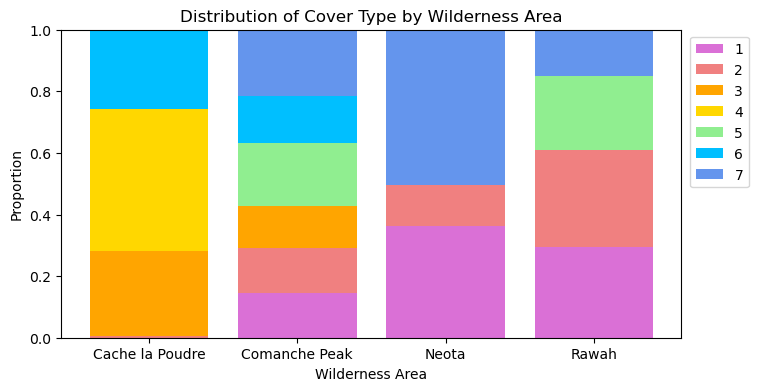

In [8]:
ct_by_wa_props = ct_by_wa / ct_by_wa.sum()
bb = np.cumsum(ct_by_wa_props) - ct_by_wa_props

plt.figure(figsize=(8, 4))
for i in range(len(ct_by_wa_props)):
    plt.bar(ct_by_wa_props.columns, ct_by_wa_props.iloc[i, :], bottom=bb.iloc[i, :], color=palette[i], label=ct_by_wa.index[i])

plt.xlabel('Wilderness Area')
plt.ylabel('Proportion')
plt.title('Distribution of Cover Type by Wilderness Area')
plt.legend(bbox_to_anchor=(1.12, 1), loc='upper right')
plt.show()

## Part 3: Distribution of Cover Type by Soil Type
Create a dataframe to determine the number of regions of each cover type there are for each of the 40 soil types.

In [9]:
ct_by_st = pd.crosstab(fc.Cover_Type, fc.Soil_Type)
ct_by_st

Soil_Type,1,2,3,4,5,6,8,9,10,11,...,31,32,33,34,35,36,37,38,39,40
Cover_Type,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,5,0,0,0,1,9,5,...,114,230,184,0,3,0,0,80,79,49
2,0,3,12,20,0,7,1,9,81,67,...,97,255,184,12,1,2,0,7,3,3
3,121,283,133,462,55,248,0,0,717,89,...,0,5,0,0,0,0,0,0,0,0
4,139,94,799,133,39,244,0,0,170,24,...,0,0,0,0,0,0,0,0,0,0
5,0,61,0,129,0,0,0,0,64,154,...,87,100,115,4,0,0,0,0,0,0
6,95,182,18,87,71,151,0,0,1101,67,...,7,30,66,2,0,0,0,0,0,0
7,0,0,0,7,0,0,0,0,0,0,...,27,70,67,4,98,8,34,641,575,407


Create a stacked bar chart to represent this dataframe

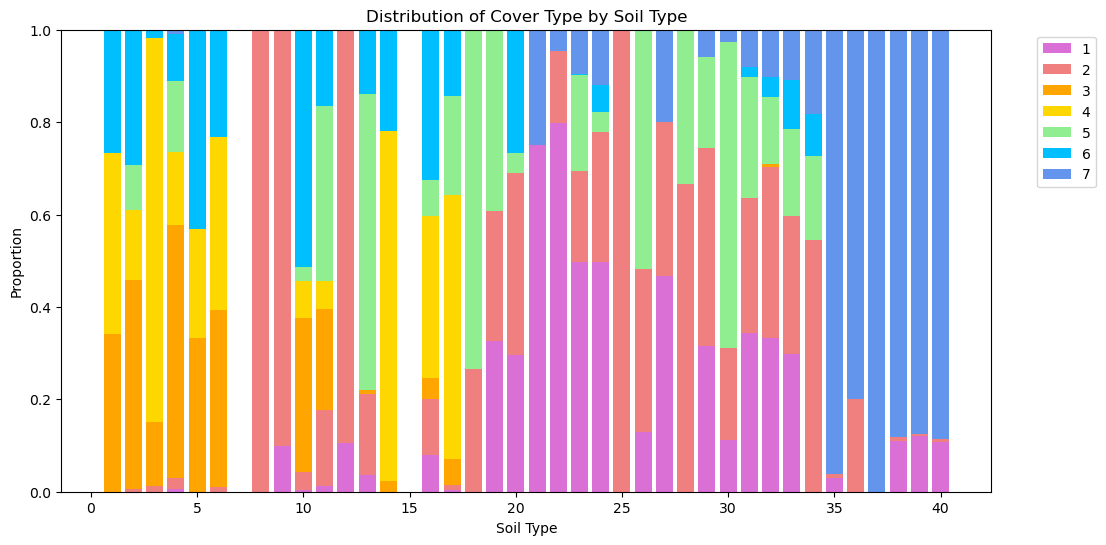

In [10]:
ct_by_st_props = ct_by_st / ct_by_st.sum()
bb = np.cumsum(ct_by_st_props) - ct_by_st_props

plt.figure(figsize=(12, 6))
for i in range(len(ct_by_st_props)):
    plt.bar(ct_by_st_props.columns, ct_by_st_props.iloc[i, :], bottom=bb.iloc[i, :], color=palette[i], label=ct_by_st.index[i])

plt.xlabel('Soil Type')
plt.ylabel('Proportion')
plt.title('Distribution of Cover Type by Soil Type')
plt.legend(bbox_to_anchor=(1.12, 1), loc='upper right')
plt.show()

## Part 4: Distribution of Elevation by Cover Type
calculate the average elevation for each of the seven Cover_Types

In [11]:
elevation_by_ct = fc.loc[:, ['Elevation', 'Cover_Type']].groupby('Cover_Type').mean()
elevation_by_ct

,Elevation
Cover_Type,
1,3128.025926
2,2922.540278
3,2398.423148
4,2223.420370
5,2786.801389
6,2423.276852
7,3362.769907


Create histograms to view the distribution of elevations for each of the seven Cover Types

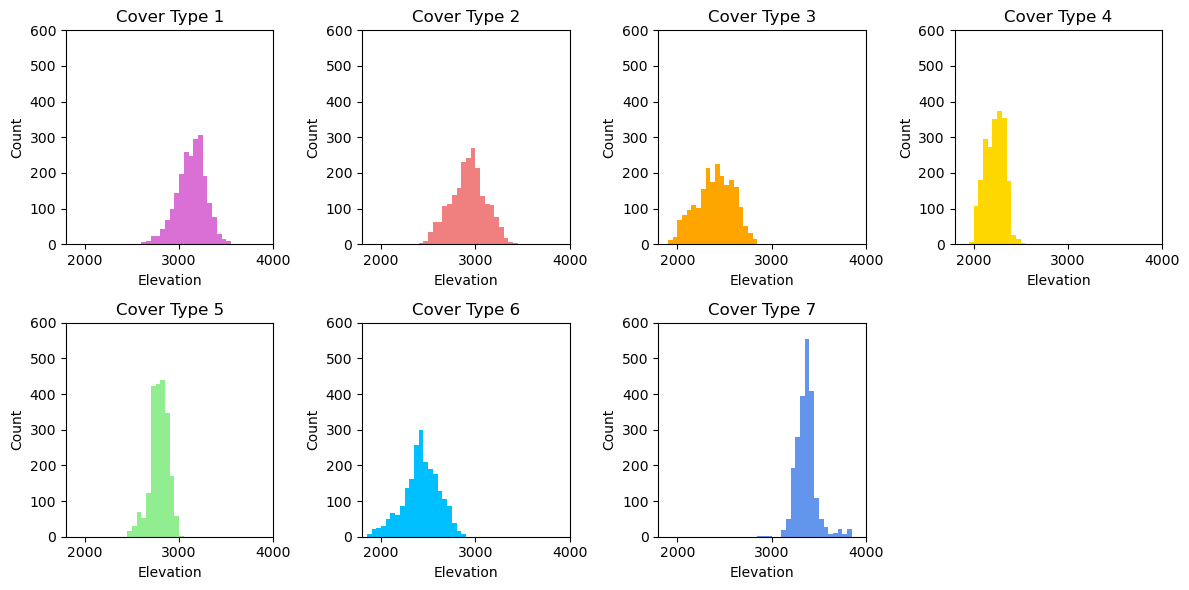

In [12]:
elevation_by_ct = fc.loc[:, ['Elevation', 'Cover_Type']].groupby('Cover_Type').mean()
elevation_by_ct

# Create histograms to view the distribution of elevations for each of the seven Cover Types
plt.figure(figsize=(12, 6))
for i in range(1, 8):
    plt.subplot(2, 4, i)
    plt.hist(fc.loc[fc.Cover_Type == i, 'Elevation'], bins=np.arange(1800, 4050, 50), color=palette[i-1])
    plt.title(f'Cover Type {i}')
    plt.xlim(1800, 4000)
    plt.ylim(0, 600)
    plt.xlabel('Elevation')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Part 5: Creating Training, Validation, and Test Sets
Separate the categorical features, numerical features, and labels

In [13]:
X_num = fc.loc[:, ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
                  'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                  'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                  'Horizontal_Distance_To_Fire_Points']].values
X_cat = fc.loc[:, ['Wilderness_Area','Soil_Type']].values
y = fc.Cover_Type.values

print(f'Numerical Feature Array Shape:   {X_num.shape}')
print(f'Categorical Feature Array Shape: {X_cat.shape}')
print(f'Label Array Shape:               {y.shape}')

Numerical Feature Array Shape:   (15120, 10)
Categorical Feature Array Shape: (15120, 2)
Label Array Shape:               (15120,)


Encode the categorical variables using One Hot Encoding

In [14]:
encoder = OneHotEncoder(sparse_output=False)
encoder.fit(X_cat)
X_enc = encoder.transform(X_cat)
print(f'Encoded Feature Array Shape: {X_enc.shape}')

Encoded Feature Array Shape: (15120, 42)


Combine the numerical features with the encoded categorical features

In [15]:
X = np.hstack((X_num, X_enc))
print(f'Feature Array Shape: {X.shape}')

Feature Array Shape: (15120, 52)


Split the data into training, validation, and test sets, using a 70/15/15 split

In [16]:
X_train, X_hold, y_train, y_hold = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_hold, y_hold, test_size=0.5, random_state=1, stratify=y_hold)

print(f'Training Features Shape:   {X_train.shape}')
print(f'Validation Features Shape: {X_valid.shape}')
print(f'Test Features Shape:       {X_test.shape}')

Training Features Shape:   (10584, 52)
Validation Features Shape: (2268, 52)
Test Features Shape:       (2268, 52)


## Part 6: Logistic Regression Model
Create and evaluate a logistic regression model

In [17]:
lr_mod = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=1, multi_class='multinomial', penalty=None)
lr_mod.fit(X_train, y_train)
print(f'Training Accuracy:   {np.round(lr_mod.score(X_train, y_train), 4)}')
print(f'Validation Accuracy: {np.round(lr_mod.score(X_valid, y_valid), 4)}')

C:\Users\BenMi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training Accuracy:   0.6128
Validation Accuracy: 0.6133


C:\Users\BenMi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Part 7: Decision Tree Models
Create decision tree models with varying depths

In [18]:
dt_train_acc = []
dt_valid_acc = []
depth_range = range(2, 31)
for depth in depth_range:
    np.random.seed(1)
    temp_tree = DecisionTreeClassifier(max_depth=depth, random_state=1)
    temp_tree.fit(X_train, y_train)
    dt_train_acc.append(temp_tree.score(X_train, y_train))
    dt_valid_acc.append(temp_tree.score(X_valid, y_valid))

dt_idx = np.argmax(dt_valid_acc)
dt_opt_depth = depth_range[dt_idx]
dt_opt_train = dt_train_acc[dt_idx]
dt_opt_val = dt_valid_acc[dt_idx]

print(f'Optimal value for max_depth:           {dt_opt_depth}')
print(f'Training Accuracy for Optimal Model:   {dt_opt_train}')
print(f'Validation Accuracy for Optimal Model: {dt_opt_val}')

Optimal value for max_depth:           18
Training Accuracy for Optimal Model:   0.9804421768707483
Validation Accuracy for Optimal Model: 0.7720458553791887


Plot the training and validation curves as a function of max_depth

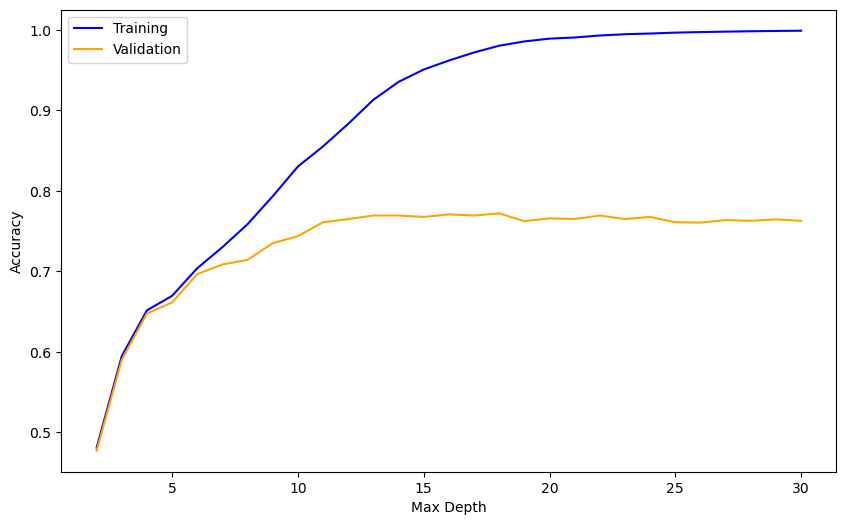

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(depth_range, dt_train_acc, label='Training', color='blue')
plt.plot(depth_range, dt_valid_acc, label='Validation', color='orange')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Part 8: Random Forest Models
Create random forest models with varying depths

In [20]:
rf_train_acc = []
rf_valid_acc = []

for depth in depth_range:
    np.random.seed(1)
    temp_forest = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=1)
    temp_forest.fit(X_train, y_train)
    rf_train_acc.append(temp_forest.score(X_train, y_train))
    rf_valid_acc.append(temp_forest.score(X_valid, y_valid))

rf_idx = np.argmax(rf_valid_acc)
rf_opt_depth = depth_range[rf_idx]
rf_opt_train_acc = rf_train_acc[rf_idx]
rf_opt_valid_acc = rf_valid_acc[rf_idx]

print(f"Optimal value for max_depth:           {rf_opt_depth}")
print(f"Training Accuracy for Optimal Model:   {rf_opt_train_acc}")
print(f"Validation Accuracy for Optimal Model: {rf_opt_valid_acc}")

Optimal value for max_depth:           28
Training Accuracy for Optimal Model:   1.0
Validation Accuracy for Optimal Model: 0.8677248677248677


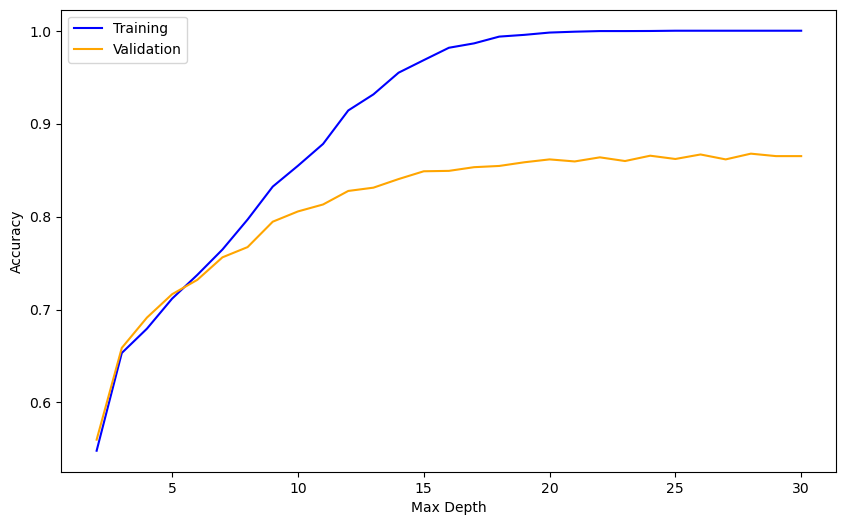

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(depth_range, rf_train_acc, label='Training', color='blue')
plt.plot(depth_range, rf_valid_acc, label='Validation', color='orange')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Part 9: Create and Evaluate Final Model
The model with the best performance was the RandomForestClassifier with a depth of 28.

In [22]:
np.random.seed(1)
final_model = RandomForestClassifier(n_estimators=100, max_depth=28, random_state=1)
final_model.fit(X_train, y_train)

print(f"Training Accuracy for Final Model:   {np.round(final_model.score(X_train, y_train), 4)}")
print(f"Validation Accuracy for Final Model: {np.round(final_model.score(X_valid, y_valid), 4)}")
print(f"Testing Accuracy for Final Model:    {np.round(final_model.score(X_test, y_test), 4)}")

Training Accuracy for Final Model:   1.0
Validation Accuracy for Final Model: 0.8677
Testing Accuracy for Final Model:    0.8593


Create and display a confusion matrix showing the model's performance on the test set

In [23]:
test_pred = final_model.predict(X_test)
cm = confusion_matrix(y_test, test_pred)
cover_type_labels = range(1, 8)
cm_df = pd.DataFrame(cm, index=cover_type_labels, columns=cover_type_labels)
cm_df

,1,2,3,4,5,6,7
1,236,63,2,0,5,0,18
2,53,239,6,0,13,10,3
3,0,2,262,18,2,40,0
4,0,0,6,313,0,5,0
5,0,11,4,0,305,4,0
6,0,0,33,11,1,279,0
7,8,1,0,0,0,0,315


Create a classification report to show more details about the model's performance

In [24]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           1       0.79      0.73      0.76       324
           2       0.76      0.74      0.75       324
           3       0.84      0.81      0.82       324
           4       0.92      0.97      0.94       324
           5       0.94      0.94      0.94       324
           6       0.83      0.86      0.84       324
           7       0.94      0.97      0.95       324

    accuracy                           0.86      2268
   macro avg       0.86      0.86      0.86      2268
weighted avg       0.86      0.86      0.86      2268

